# CNN + ejercicios sugeridos con BreastMNIST

En este notebook voy a desarrollar los ejercicios sugeridos de la práctica usando **BreastMNIST**.

Elegí este dataset porque ya es un problema **binario** y es pequeño, así que es práctico para ejecutarlo en Google Colab:

- **Clase 0:** malignant
- **Clase 1:** normal / benign
- **Total:** 780 imágenes
- **Train:** 546
- **Validation:** 78
- **Test:** 156

Voy a mantener la idea del notebook base: entrenar una CNN, evaluar con Accuracy y ROC-AUC, trabajar con Data Augmentation, hacer Transfer Learning y revisar interpretabilidad.

Además voy a completar los 5 ejercicios sugeridos:

1. Modificar la arquitectura de la CNN.
2. Probar distintos learning rates y un scheduler.
3. Comparar distintos niveles de Data Augmentation.
4. Cambiar el dataset y adaptar el pipeline.
5. Calibrar probabilidades y analizar curvas ROC.



## 1. Preparación del entorno

Primero instalo MedMNIST e importo las librerías que voy a necesitar.  
También fijo una semilla para que los resultados sean más reproducibles.

In [1]:
import sys
import subprocess

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "medmnist"]
)
print("MedMNIST listo.")

MedMNIST listo.


In [2]:
import copy
import random
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models

from torch.utils.data import DataLoader

import medmnist
from medmnist import INFO

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from IPython.display import display

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo:", device)

Dispositivo: cuda


## 2. Cargar BreastMNIST

En vez de usar PneumoniaMNIST o seleccionar dos clases de un dataset multiclase, aquí utilizo **BreastMNIST directamente**, porque ya tiene exactamente dos clases.

Esto hace que el pipeline sea más simple: no necesito filtrar ni recodificar categorías.

In [3]:
data_flag = "breastmnist"

info = INFO[data_flag]
DataClass = getattr(
    medmnist,
    info["python_class"]
)

print("Dataset:", data_flag)
print("Tarea:", info["task"])
print("Canales:", info["n_channels"])
print("Etiquetas:", info["label"])
print("Cantidad de imágenes:", info["n_samples"])

Dataset: breastmnist
Tarea: binary-class
Canales: 1
Etiquetas: {'0': 'malignant', '1': 'normal, benign'}
Cantidad de imágenes: {'train': 546, 'val': 78, 'test': 156}


### 2.1. Transformación base y particiones

Como BreastMNIST está en escala de grises, la normalización usa un solo canal.

No aplico aumentos en VALIDATION ni TEST.

In [4]:
transform_base = T.Compose([
    T.ToTensor(),
    T.Normalize(
        mean=(0.5,),
        std=(0.5,)
    )
])

train_dataset = DataClass(
    split="train",
    transform=transform_base,
    download=True
)

val_dataset = DataClass(
    split="val",
    transform=transform_base,
    download=True
)

test_dataset = DataClass(
    split="test",
    transform=transform_base,
    download=True
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

100%|██████████| 560k/560k [00:00<00:00, 923kB/s]

Train: 546
Validation: 78
Test: 156


### 2.2. Visualizar algunas imágenes

Antes de entrenar, reviso ejemplos para comprobar que las imágenes y etiquetas se estén cargando correctamente.

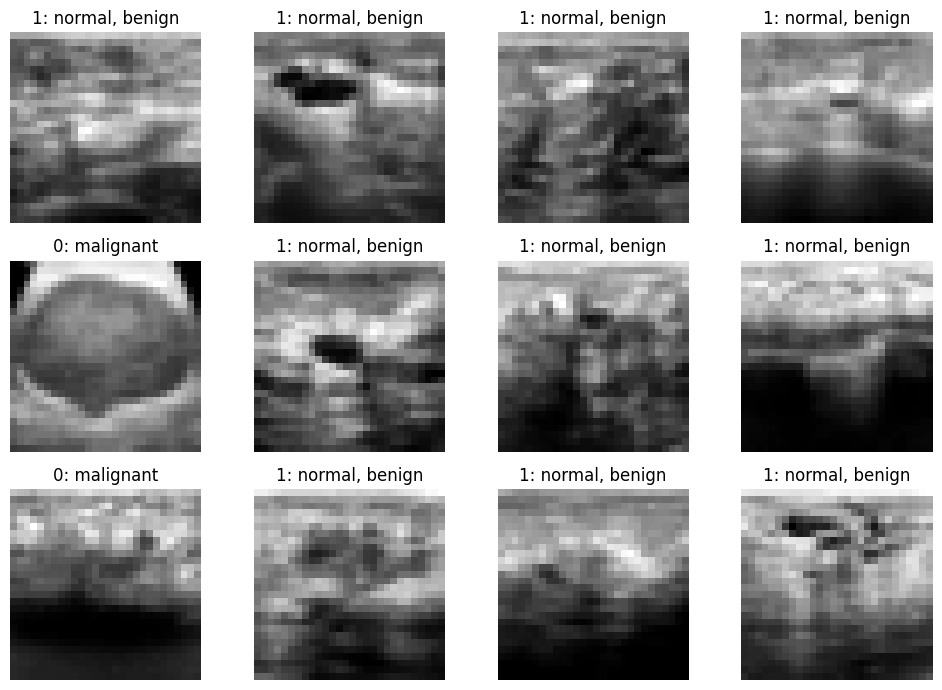

In [5]:
class_names = [
    info["label"]["0"],
    info["label"]["1"]
]

def undo_normalization(x):
    return torch.clamp(
        x * 0.5 + 0.5,
        0,
        1
    )

def show_examples(dataset, n=12):
    n = min(n, len(dataset))

    plt.figure(figsize=(10, 7))

    for i in range(n):
        x, y = dataset[i]

        plt.subplot(3, 4, i + 1)

        img = undo_normalization(x).squeeze(0)

        plt.imshow(
            img,
            cmap="gray"
        )

        label = int(
            np.asarray(y).squeeze()
        )

        plt.title(
            f"{label}: {class_names[label]}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_examples(
    train_dataset,
    n=12
)

## 3. DataLoaders

Uso lotes de 64 imágenes. Como el dataset es pequeño, dejo `num_workers=0` para que el notebook sea más simple y estable en Colab.

In [6]:
batch_size = 64

loader_kwargs = {
    "batch_size": batch_size,
    "num_workers": 0,
    "pin_memory": device.type == "cuda"
}

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_kwargs
)

# Lo uso para medir métricas de TRAIN sin mezclar el orden.
train_eval_loader = DataLoader(
    train_dataset,
    shuffle=False,
    **loader_kwargs
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_kwargs
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_kwargs
)

xb, yb = next(
    iter(train_loader)
)

print("Batch imágenes:", xb.shape)
print("Batch etiquetas:", yb.shape)

Batch imágenes: torch.Size([64, 1, 28, 28])
Batch etiquetas: torch.Size([64, 1])


### 3.1. Peso de las clases

BreastMNIST no tiene exactamente la misma cantidad de ejemplos en las dos clases.

Voy a compensar ese desbalance, pero de forma **moderada**. En una primera prueba un peso demasiado fuerte podía hacer que el modelo favoreciera demasiado a la clase minoritaria y producir una Accuracy baja aunque el ROC-AUC fuera aceptable.

Por eso utilizo una ponderación basada en la raíz cuadrada de la frecuencia inversa. Así mantengo la ayuda a la clase minoritaria sin alterar demasiado el umbral de decisión.

In [7]:
train_labels = np.asarray(
    train_dataset.labels
).reshape(-1).astype(int)

counts = np.bincount(
    train_labels,
    minlength=2
)

# Uso una corrección moderada del desbalance.
# La raíz cuadrada evita que la clase minoritaria reciba un peso excesivo.
weights_np = np.sqrt(
    counts.sum()
    / (2.0 * counts)
)

weights_np = (
    weights_np
    / weights_np.mean()
)

class_weights = torch.tensor(
    weights_np,
    dtype=torch.float32,
    device=device
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("Cantidad por clase:", counts)
print("Pesos usados:", weights_np.round(4))

Cantidad por clase: [147 399]
Pesos usados: [1.2446 0.7554]


## 4. Funciones de entrenamiento y evaluación

Voy a guardar tanto la pérdida de entrenamiento como la pérdida de validación.

Esto es importante porque en la gráfica de **Loss** quiero ver las dos líneas:

- **Train Loss**
- **Validation Loss**

También guardaré:

- Validation Accuracy
- Validation ROC-AUC
- Learning Rate

In [8]:
@torch.no_grad()
def evaluate_network(model, loader, loss_fn):
    model.eval()

    losses = []
    labels_all = []
    probs_all = []
    preds_all = []

    for x, y in loader:
        x = x.to(
            device,
            non_blocking=True
        )

        y = y.to(
            device,
            non_blocking=True
        ).long().view(-1)

        logits = model(x)

        loss = loss_fn(
            logits,
            y
        )

        probs = torch.softmax(
            logits,
            dim=1
        )[:, 1]

        preds = torch.argmax(
            logits,
            dim=1
        )

        losses.append(
            loss.item()
        )

        labels_all.append(
            y.cpu().numpy()
        )

        probs_all.append(
            probs.cpu().numpy()
        )

        preds_all.append(
            preds.cpu().numpy()
        )

    y_true = np.concatenate(
        labels_all
    )

    y_prob = np.concatenate(
        probs_all
    )

    y_pred = np.concatenate(
        preds_all
    )

    avg_loss = float(
        np.mean(losses)
    )

    acc = accuracy_score(
        y_true,
        y_pred
    )

    auc = roc_auc_score(
        y_true,
        y_prob
    )

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "auc": auc,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob
    }


def train_epoch(
    model,
    loader,
    optimizer,
    loss_fn
):
    model.train()

    losses = []

    for x, y in loader:
        x = x.to(
            device,
            non_blocking=True
        )

        y = y.to(
            device,
            non_blocking=True
        ).long().view(-1)

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(x)

        loss = loss_fn(
            logits,
            y
        )

        loss.backward()

        # Evita actualizaciones demasiado bruscas.
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        losses.append(
            loss.item()
        )

    return float(
        np.mean(losses)
    )

In [9]:
def fit_model(
    model,
    train_dl,
    val_dl,
    train_eval_dl=None,
    lr=3e-4,
    scheduler_kind="plateau",
    epochs=20,
    patience=5,
    verbose=True
):
    if train_eval_dl is None:
        train_eval_dl = train_dl

    trainable = [
        p for p in model.parameters()
        if p.requires_grad
    ]

    optimizer = torch.optim.AdamW(
        trainable,
        lr=lr,
        weight_decay=1e-4
    )

    if scheduler_kind == "plateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=2,
            threshold=1e-3,
            min_lr=1e-6
        )

    elif scheduler_kind == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=epochs,
            eta_min=1e-6
        )

    else:
        scheduler = None

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_auc": [],
        "val_auc": [],
        "lr": []
    }

    best_loss = float("inf")
    best_state = copy.deepcopy(
        model.state_dict()
    )

    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):

        train_loss = train_epoch(
            model,
            train_dl,
            optimizer,
            criterion
        )

        train_result = evaluate_network(
            model,
            train_eval_dl,
            criterion
        )

        val_result = evaluate_network(
            model,
            val_dl,
            criterion
        )

        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_result["loss"]
        )

        history["train_acc"].append(
            train_result["accuracy"]
        )

        history["val_acc"].append(
            val_result["accuracy"]
        )

        history["train_auc"].append(
            train_result["auc"]
        )

        history["val_auc"].append(
            val_result["auc"]
        )

        history["lr"].append(
            current_lr
        )

        if scheduler_kind == "plateau":
            scheduler.step(
                val_result["loss"]
            )

        elif scheduler_kind == "cosine":
            scheduler.step()

        if verbose:
            print(
                f"Época {epoch:02d} | "
                f"train_loss={train_loss:.4f} | "
                f"val_loss={val_result['loss']:.4f} | "
                f"train_acc={train_result['accuracy']:.4f} | "
                f"val_acc={val_result['accuracy']:.4f} | "
                f"train_auc={train_result['auc']:.4f} | "
                f"val_auc={val_result['auc']:.4f} | "
                f"lr={current_lr:.2e}"
            )

        if val_result["loss"] < best_loss - 1e-3:
            best_loss = val_result["loss"]

            best_state = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            if verbose:
                print("Early stopping.")
            break

    model.load_state_dict(
        best_state
    )

    return model, history


def interpret_history(history, model_name):
    best_loss_epoch = int(
        np.argmin(history["val_loss"]) + 1
    )

    best_auc = float(
        np.max(history["val_auc"])
    )

    best_acc = float(
        np.max(history["val_acc"])
    )

    last_train_auc = float(
        history["train_auc"][-1]
    )

    last_val_auc = float(
        history["val_auc"][-1]
    )

    auc_gap = (
        last_train_auc
        - last_val_auc
    )

    print(f"\nINTERPRETACIÓN - {model_name}")
    print("-" * 60)
    print(
        f"Mejor Validation Loss en época {best_loss_epoch}."
    )
    print(
        f"Mejor Validation Accuracy: {best_acc:.4f}"
    )
    print(
        f"Mejor Validation ROC-AUC: {best_auc:.4f}"
    )

    if best_auc >= 0.90:
        print(
            "El ROC-AUC de validación muestra una separación alta entre las dos clases."
        )
    elif best_auc >= 0.80:
        print(
            "El ROC-AUC de validación muestra una buena capacidad de separación."
        )
    elif best_auc >= 0.70:
        print(
            "El ROC-AUC es moderado: el modelo aprende, pero todavía tiene margen de mejora."
        )
    elif best_auc >= 0.60:
        print(
            "El ROC-AUC es bajo/modesto. Para una CNN base puede servir como referencia, pero no sería el modelo final."
        )
    else:
        print(
            "El ROC-AUC está cerca del azar y sería necesario revisar el modelo o el entrenamiento."
        )

    if auc_gap > 0.10:
        print(
            "Hay una diferencia apreciable entre TRAIN y VALIDATION; esto puede indicar sobreajuste."
        )
    else:
        print(
            "La diferencia entre TRAIN y VALIDATION no muestra un sobreajuste fuerte."
        )

    if max(history["train_auc"]) >= 0.995 or best_auc >= 0.995:
        print(
            "Alguna métrica se acercó a 1.0. Eso NO es automáticamente un error; se revisa junto con Validation Loss y la diferencia TRAIN-VALIDATION."
        )

## 5. CNN base

Primero entreno una CNN sencilla parecida a la idea del ejemplo inicial.

La usaré como punto de comparación antes de cambiar la arquitectura.

In [10]:
class BaseCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                1, 16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                16, 32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                64,
                2
            )
        )

    def forward(self, x):
        x = self.features(x)
        return self.head(x)


base_model = BaseCNN().to(
    device
)

n_params = sum(
    p.numel()
    for p in base_model.parameters()
)

print(
    "Parámetros de la CNN base:",
    f"{n_params:,}"
)

Parámetros de la CNN base: 23,426


In [11]:
base_model, history_base = fit_model(
    base_model,
    train_loader,
    val_loader,
    train_eval_dl=train_eval_loader,
    lr=3e-4,
    scheduler_kind="plateau",
    epochs=25,
    patience=6,
    verbose=True
)

Época 01 | train_loss=0.6850 | val_loss=0.6827 | train_acc=0.7308 | val_acc=0.7308 | train_auc=0.4266 | val_auc=0.5079 | lr=3.00e-04
Época 02 | train_loss=0.6739 | val_loss=0.6798 | train_acc=0.7308 | val_acc=0.7308 | train_auc=0.4251 | val_auc=0.5054 | lr=3.00e-04
Época 03 | train_loss=0.6683 | val_loss=0.6823 | train_acc=0.7308 | val_acc=0.7308 | train_auc=0.4456 | val_auc=0.5213 | lr=3.00e-04
Época 04 | train_loss=0.6647 | val_loss=0.6803 | train_acc=0.7308 | val_acc=0.7308 | train_auc=0.5861 | val_auc=0.5890 | lr=3.00e-04
Época 05 | train_loss=0.6569 | val_loss=0.6775 | train_acc=0.7308 | val_acc=0.7308 | train_auc=0.6609 | val_auc=0.5965 | lr=3.00e-04
Época 06 | train_loss=0.6507 | val_loss=0.6777 | train_acc=0.7308 | val_acc=0.7308 | train_auc=0.6619 | val_auc=0.5973 | lr=3.00e-04
Época 07 | train_loss=0.6510 | val_loss=0.6809 | train_acc=0.7308 | val_acc=0.7308 | train_auc=0.6663 | val_auc=0.6015 | lr=3.00e-04
Época 08 | train_loss=0.6449 | val_loss=0.6772 | train_acc=0.7308 | v

### 5.1. Curvas de entrenamiento

Para revisar correctamente el entrenamiento separo las métricas en tres gráficos:

1. **Train Loss vs Validation Loss**  
2. **Train Accuracy vs Validation Accuracy**  
3. **Train ROC-AUC vs Validation ROC-AUC**

Las curvas se muestran como líneas continuas, sin puntos, para que la lectura sea más limpia.

> **Importante:** que Accuracy o ROC-AUC lleguen a `1.0` no significa por sí solo que algo esté mal. El problema se llama **sobreajuste (overfitting)** cuando TRAIN mejora mucho o se acerca a 1 mientras VALIDATION deja de mejorar, empeora o aumenta su pérdida.
>
> Un ROC-AUC cercano a `0.5` es parecido al azar; alrededor de `0.6` es todavía débil; `0.8` ya es bueno y `0.9` o más representa una separación alta. Estos valores se interpretan junto con la pérdida y con la diferencia entre TRAIN y VALIDATION.

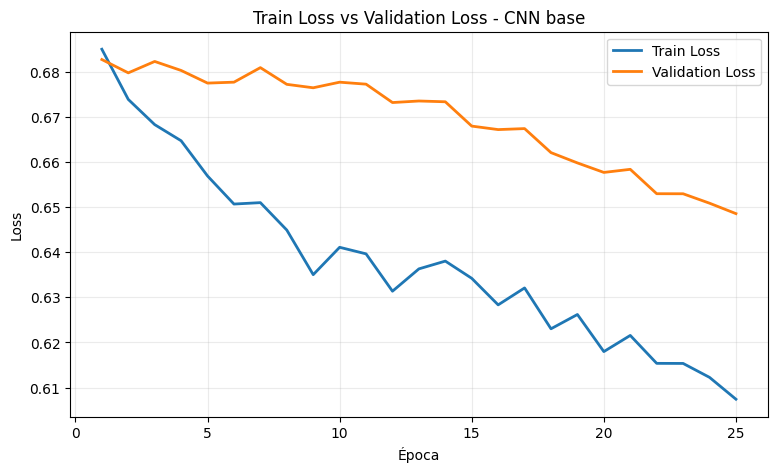

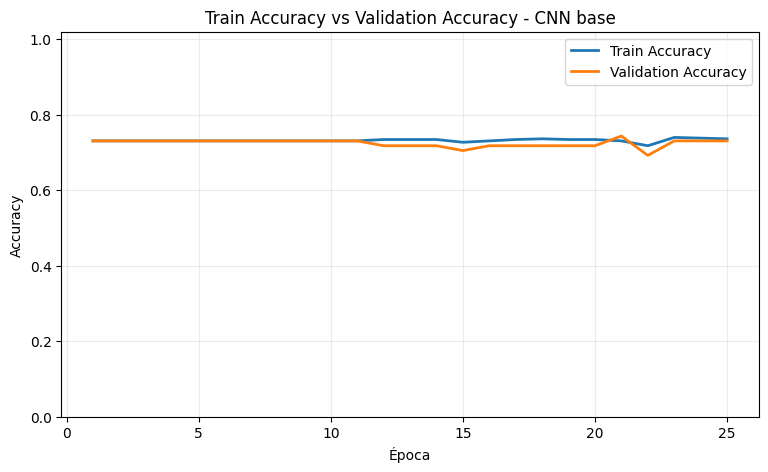

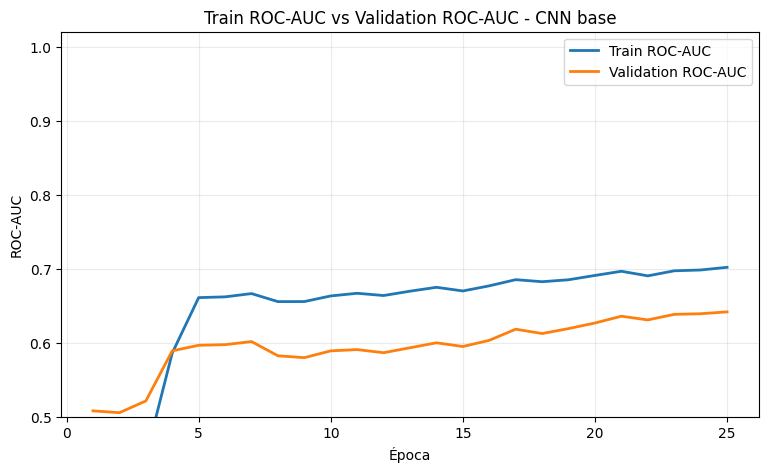


INTERPRETACIÓN - CNN base
------------------------------------------------------------
Mejor Validation Loss en época 25.
Mejor Validation Accuracy: 0.7436
Mejor Validation ROC-AUC: 0.6416
El ROC-AUC es bajo/modesto. Para una CNN base puede servir como referencia, pero no sería el modelo final.
La diferencia entre TRAIN y VALIDATION no muestra un sobreajuste fuerte.


In [12]:
epochs_base = np.arange(
    1,
    len(history_base["train_loss"]) + 1
)

plt.figure(figsize=(9, 5))

plt.plot(
    epochs_base,
    history_base["train_loss"],
    linewidth=2,
    label="Train Loss"
)

plt.plot(
    epochs_base,
    history_base["val_loss"],
    linewidth=2,
    label="Validation Loss"
)

plt.title(
    "Train Loss vs Validation Loss - CNN base"
)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


plt.figure(figsize=(9, 5))

plt.plot(
    epochs_base,
    history_base["train_acc"],
    linewidth=2,
    label="Train Accuracy"
)

plt.plot(
    epochs_base,
    history_base["val_acc"],
    linewidth=2,
    label="Validation Accuracy"
)

plt.title(
    "Train Accuracy vs Validation Accuracy - CNN base"
)

plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.ylim(0, 1.02)
plt.legend()
plt.grid(alpha=0.25)
plt.show()


plt.figure(figsize=(9, 5))

plt.plot(
    epochs_base,
    history_base["train_auc"],
    linewidth=2,
    label="Train ROC-AUC"
)

plt.plot(
    epochs_base,
    history_base["val_auc"],
    linewidth=2,
    label="Validation ROC-AUC"
)

plt.title(
    "Train ROC-AUC vs Validation ROC-AUC - CNN base"
)

plt.xlabel("Época")
plt.ylabel("ROC-AUC")
plt.ylim(0.5, 1.02)
plt.legend()
plt.grid(alpha=0.25)
plt.show()

interpret_history(
    history_base,
    "CNN base"
)

# Ejercicio 1. Cambiar la arquitectura de la CNN

Para este ejercicio no voy a copiar la misma modificación del ejemplo.

Voy a crear una segunda CNN con tres cambios:

- más filtros: **24 → 48 → 96**;
- **BatchNorm2d** después de cada convolución;
- un **Dropout** pequeño antes de la salida.

Después compararé la CNN base y la CNN modificada usando VALIDATION.

In [13]:
class ImprovedCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                1, 24,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(24),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                24, 48,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(48),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                48, 96,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(96),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.25),
            nn.Linear(
                96,
                2
            )
        )

    def forward(self, x):
        x = self.features(x)
        return self.head(x)


improved_model = ImprovedCNN().to(
    device
)

improved_model, history_improved = fit_model(
    improved_model,
    train_loader,
    val_loader,
    train_eval_dl=train_eval_loader,
    lr=3e-4,
    scheduler_kind="plateau",
    epochs=20,
    patience=5,
    verbose=False
)

print("Entrenamiento de la CNN modificada terminado.")

Entrenamiento de la CNN modificada terminado.


In [14]:
architecture_results = pd.DataFrame([
    {
        "Modelo": "CNN base",
        "Mejor Val Loss": min(
            history_base["val_loss"]
        ),
        "Mejor Val Accuracy": max(
            history_base["val_acc"]
        ),
        "Mejor Val ROC-AUC": max(
            history_base["val_auc"]
        )
    },
    {
        "Modelo": "CNN + BatchNorm + Dropout",
        "Mejor Val Loss": min(
            history_improved["val_loss"]
        ),
        "Mejor Val Accuracy": max(
            history_improved["val_acc"]
        ),
        "Mejor Val ROC-AUC": max(
            history_improved["val_auc"]
        )
    }
])

display(
    architecture_results.round(4)
)

,Modelo,Mejor Val Loss,Mejor Val Accuracy,Mejor Val ROC-AUC
0,CNN base,0.6486,0.7436,0.6416
1,CNN + BatchNorm + Dropout,0.3766,0.8333,0.8864


### Interpretación de la arquitectura

Además de la tabla, comparo las curvas de validación de la CNN base y la CNN modificada.  
No busco que una métrica llegue artificialmente a 1; busco que la pérdida disminuya y que las métricas de validación mejoren sin separarse demasiado de TRAIN.

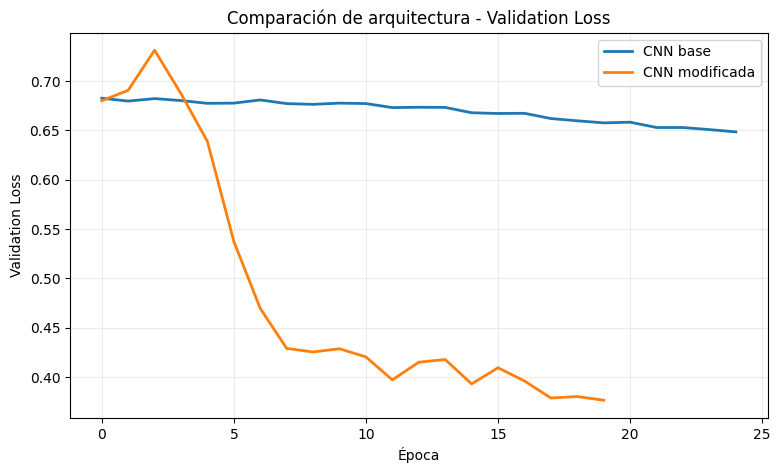

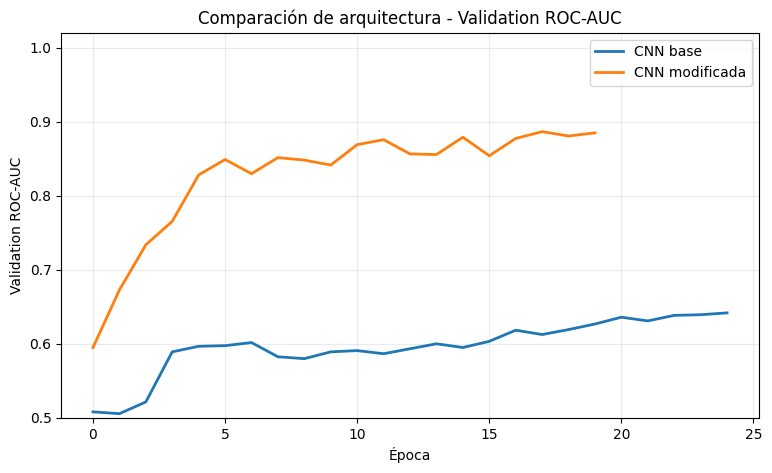


INTERPRETACIÓN - CNN modificada
------------------------------------------------------------
Mejor Validation Loss en época 20.
Mejor Validation Accuracy: 0.8333
Mejor Validation ROC-AUC: 0.8864
El ROC-AUC de validación muestra una buena capacidad de separación.
La diferencia entre TRAIN y VALIDATION no muestra un sobreajuste fuerte.


In [15]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_base["val_loss"],
    linewidth=2,
    label="CNN base"
)

plt.plot(
    history_improved["val_loss"],
    linewidth=2,
    label="CNN modificada"
)

plt.title(
    "Comparación de arquitectura - Validation Loss"
)

plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


plt.figure(figsize=(9, 5))

plt.plot(
    history_base["val_auc"],
    linewidth=2,
    label="CNN base"
)

plt.plot(
    history_improved["val_auc"],
    linewidth=2,
    label="CNN modificada"
)

plt.title(
    "Comparación de arquitectura - Validation ROC-AUC"
)

plt.xlabel("Época")
plt.ylabel("Validation ROC-AUC")
plt.ylim(0.5, 1.02)
plt.legend()
plt.grid(alpha=0.25)
plt.show()

interpret_history(
    history_improved,
    "CNN modificada"
)

**Interpretación:** la arquitectura modificada se evalúa por su comportamiento en VALIDATION.  
Si obtiene menor Validation Loss y mayor ROC-AUC que la CNN base, significa que los cambios de BatchNorm, Dropout y número de filtros ayudaron en esta ejecución. Si no mejora, el ejercicio sigue siendo válido porque precisamente se está midiendo el efecto del cambio.

# Ejercicio 2. Learning Rate y Scheduler

En la ejecución anterior las configuraciones con `LR = 0.001` hicieron que **Validation Loss aumentara muy rápido** y el early stopping terminara el entrenamiento en pocas épocas.

Eso no significa que debamos agregar épocas sin control. Primero conviene usar tasas un poco más suaves y luego permitir más épocas con **early stopping**.

Ahora comparo:

1. `LR = 0.0005`, sin scheduler.
2. `LR = 0.0002`, sin scheduler.
3. `LR = 0.0005` con `CosineAnnealingLR`.

Cada configuración puede entrenar hasta **20 épocas**, pero se detiene antes si VALIDATION deja de mejorar.

In [16]:
lr_configs = {
    "LR 0.0005": {
        "lr": 5e-4,
        "scheduler": None
    },
    "LR 0.0002": {
        "lr": 2e-4,
        "scheduler": None
    },
    "LR 0.0005 + Cosine": {
        "lr": 5e-4,
        "scheduler": "cosine"
    }
}

lr_models = {}
lr_histories = {}

for name, cfg in lr_configs.items():

    print("Entrenando:", name)

    model_tmp = ImprovedCNN().to(
        device
    )

    model_tmp, history_tmp = fit_model(
        model_tmp,
        train_loader,
        val_loader,
        train_eval_dl=train_eval_loader,
        lr=cfg["lr"],
        scheduler_kind=cfg["scheduler"],
        epochs=20,
        patience=5,
        verbose=False
    )

    lr_models[name] = model_tmp
    lr_histories[name] = history_tmp

    print(
        "  mejor val_loss =",
        f"{min(history_tmp['val_loss']):.4f}",
        "| mejor val_acc =",
        f"{max(history_tmp['val_acc']):.4f}",
        "| mejor val_auc =",
        f"{max(history_tmp['val_auc']):.4f}"
    )

Entrenando: LR 0.0005
  mejor val_loss = 0.3398 | mejor val_acc = 0.8590 | mejor val_auc = 0.9265
Entrenando: LR 0.0002
  mejor val_loss = 0.3484 | mejor val_acc = 0.8718 | mejor val_auc = 0.9165
Entrenando: LR 0.0005 + Cosine
  mejor val_loss = 0.3225 | mejor val_acc = 0.8974 | mejor val_auc = 0.9140


In [17]:
lr_results = []

for name, history in lr_histories.items():
    lr_results.append({
        "Configuración": name,
        "Mejor Val Loss": min(
            history["val_loss"]
        ),
        "Mejor Val Accuracy": max(
            history["val_acc"]
        ),
        "Mejor Val ROC-AUC": max(
            history["val_auc"]
        )
    })

lr_results = pd.DataFrame(
    lr_results
)

display(
    lr_results.round(4)
)

best_lr_name = lr_results.loc[
    lr_results["Mejor Val Loss"].idxmin(),
    "Configuración"
]

best_lr_cfg = lr_configs[
    best_lr_name
]

print(
    "Configuración elegida con VALIDATION:",
    best_lr_name
)

,Configuración,Mejor Val Loss,Mejor Val Accuracy,Mejor Val ROC-AUC
0,LR 0.0005,0.3398,0.8590,0.9265
1,LR 0.0002,0.3484,0.8718,0.9165
2,LR 0.0005 + Cosine,0.3225,0.8974,0.9140


Configuración elegida con VALIDATION: LR 0.0005 + Cosine


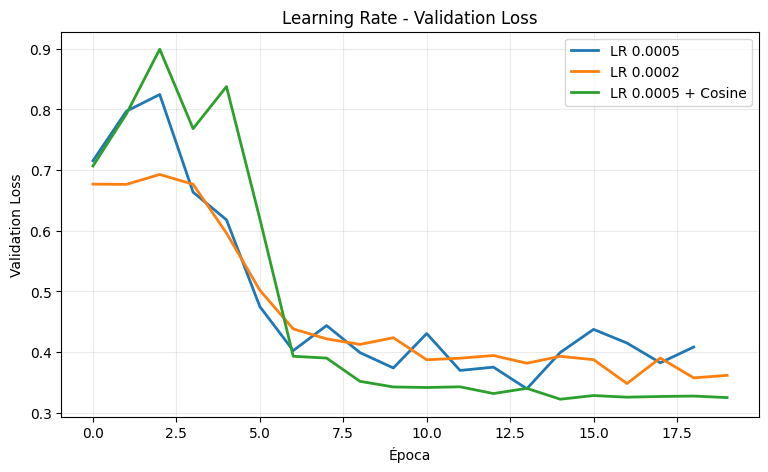

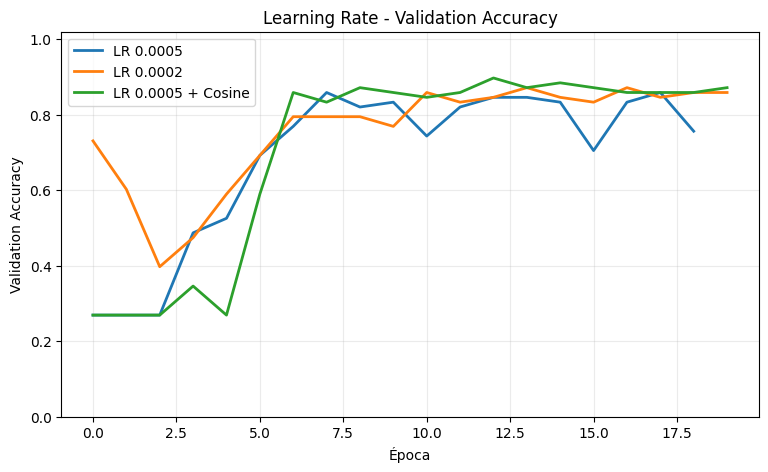

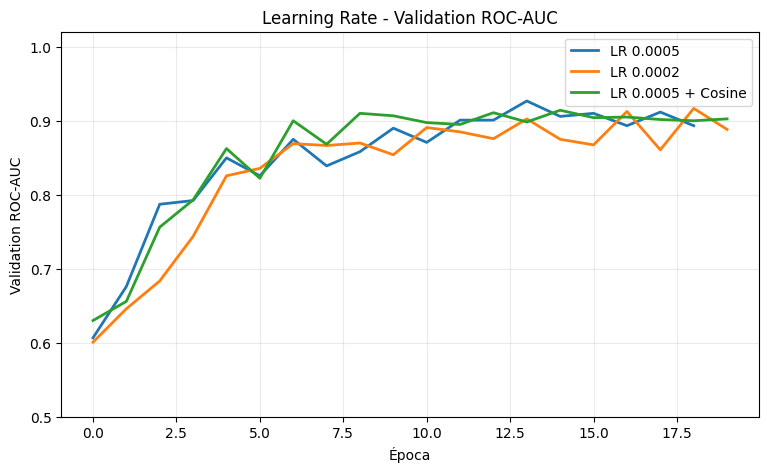

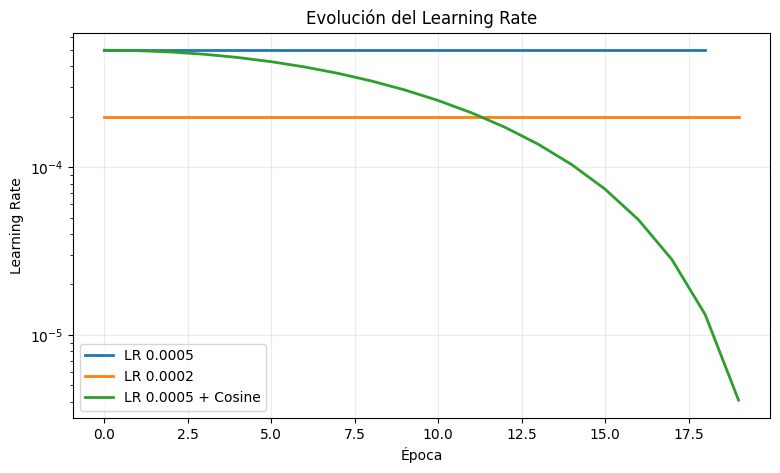

In [18]:
plt.figure(figsize=(9, 5))

for name, history in lr_histories.items():
    plt.plot(
        history["val_loss"],
        linewidth=2,
        label=name
    )

plt.title(
    "Learning Rate - Validation Loss"
)

plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


plt.figure(figsize=(9, 5))

for name, history in lr_histories.items():
    plt.plot(
        history["val_acc"],
        linewidth=2,
        label=name
    )

plt.title(
    "Learning Rate - Validation Accuracy"
)

plt.xlabel("Época")
plt.ylabel("Validation Accuracy")
plt.ylim(0, 1.02)
plt.legend()
plt.grid(alpha=0.25)
plt.show()


plt.figure(figsize=(9, 5))

for name, history in lr_histories.items():
    plt.plot(
        history["val_auc"],
        linewidth=2,
        label=name
    )

plt.title(
    "Learning Rate - Validation ROC-AUC"
)

plt.xlabel("Época")
plt.ylabel("Validation ROC-AUC")
plt.ylim(0.5, 1.02)
plt.legend()
plt.grid(alpha=0.25)
plt.show()


plt.figure(figsize=(9, 5))

for name, history in lr_histories.items():
    plt.plot(
        history["lr"],
        linewidth=2,
        label=name
    )

plt.title(
    "Evolución del Learning Rate"
)

plt.xlabel("Época")
plt.ylabel("Learning Rate")
plt.yscale("log")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

#### Interpretación del Learning Rate

La mejor configuración se selecciona por **menor Validation Loss**. También reviso Accuracy y ROC-AUC para asegurarme de que la elección sea coherente.

Una curva de Validation Loss que sube desde las primeras épocas suele indicar que el learning rate es demasiado agresivo o que el modelo comienza a sobreajustar. En cambio, una reducción gradual de la pérdida con métricas estables indica un entrenamiento más saludable.

In [19]:
print("INTERPRETACIÓN DEL EXPERIMENTO DE LEARNING RATE")
print("-" * 60)

for _, row in lr_results.iterrows():
    print(
        f"{row['Configuración']}: "
        f"Val Loss={row['Mejor Val Loss']:.4f} | "
        f"Val Accuracy={row['Mejor Val Accuracy']:.4f} | "
        f"Val ROC-AUC={row['Mejor Val ROC-AUC']:.4f}"
    )

print()
print(
    "Configuración seleccionada por menor Validation Loss:",
    best_lr_name
)

INTERPRETACIÓN DEL EXPERIMENTO DE LEARNING RATE
------------------------------------------------------------
LR 0.0005: Val Loss=0.3398 | Val Accuracy=0.8590 | Val ROC-AUC=0.9265
LR 0.0002: Val Loss=0.3484 | Val Accuracy=0.8718 | Val ROC-AUC=0.9165
LR 0.0005 + Cosine: Val Loss=0.3225 | Val Accuracy=0.8974 | Val ROC-AUC=0.9140

Configuración seleccionada por menor Validation Loss: LR 0.0005 + Cosine


# Ejercicio 3. Analizar diferentes aumentos de datos

Compararé tres situaciones:

- **Sin aumento**.
- **Aumento suave**.
- **Aumento moderado**.

Solo TRAIN recibe transformaciones aleatorias.  
VALIDATION y TEST permanecen sin aumento.

In [20]:
transform_no_aug = T.Compose([
    T.ToTensor(),
    T.Normalize(
        mean=(0.5,),
        std=(0.5,)
    )
])

transform_soft_aug = T.Compose([
    T.RandomRotation(
        degrees=5
    ),
    T.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        scale=(0.98, 1.02)
    ),
    T.ToTensor(),
    T.Normalize(
        mean=(0.5,),
        std=(0.5,)
    )
])

transform_moderate_aug = T.Compose([
    T.RandomRotation(
        degrees=10
    ),
    T.RandomAffine(
        degrees=0,
        translate=(0.06, 0.06),
        scale=(0.95, 1.05)
    ),
    T.ColorJitter(
        brightness=0.08,
        contrast=0.08
    ),
    T.ToTensor(),
    T.Normalize(
        mean=(0.5,),
        std=(0.5,)
    )
])

augmentation_transforms = {
    "Sin aumento": transform_no_aug,
    "Aumento suave": transform_soft_aug,
    "Aumento moderado": transform_moderate_aug
}

In [21]:
aug_models = {}
aug_histories = {}

for name, transform in augmentation_transforms.items():

    train_aug_dataset = DataClass(
        split="train",
        transform=transform,
        download=True
    )

    train_aug_loader = DataLoader(
        train_aug_dataset,
        shuffle=True,
        **loader_kwargs
    )

    print("Entrenando:", name)

    model_tmp = ImprovedCNN().to(
        device
    )

    model_tmp, history_tmp = fit_model(
        model_tmp,
        train_aug_loader,
        val_loader,
        train_eval_dl=train_eval_loader,
        lr=best_lr_cfg["lr"],
        scheduler_kind=best_lr_cfg["scheduler"],
        epochs=20,
        patience=5,
        verbose=False
    )

    aug_models[name] = model_tmp
    aug_histories[name] = history_tmp

    print(
        "  val_loss =",
        f"{min(history_tmp['val_loss']):.4f}",
        "| val_auc =",
        f"{max(history_tmp['val_auc']):.4f}"
    )

Entrenando: Sin aumento
  val_loss = 0.3252 | val_auc = 0.9131
Entrenando: Aumento suave
  val_loss = 0.3849 | val_auc = 0.8688
Entrenando: Aumento moderado
  val_loss = 0.4046 | val_auc = 0.8830


In [22]:
augmentation_results = []

for name, history in aug_histories.items():

    augmentation_results.append({
        "Configuración": name,
        "Mejor Val Loss": min(
            history["val_loss"]
        ),
        "Mejor Val Accuracy": max(
            history["val_acc"]
        ),
        "Mejor Val ROC-AUC": max(
            history["val_auc"]
        )
    })

augmentation_results = pd.DataFrame(
    augmentation_results
)

display(
    augmentation_results.round(4)
)

best_aug_name = augmentation_results.loc[
    augmentation_results[
        "Mejor Val ROC-AUC"
    ].idxmax(),
    "Configuración"
]

best_cnn_model = aug_models[
    best_aug_name
]

print(
    "Aumento elegido con VALIDATION:",
    best_aug_name
)

,Configuración,Mejor Val Loss,Mejor Val Accuracy,Mejor Val ROC-AUC
0,Sin aumento,0.3252,0.8718,0.9131
1,Aumento suave,0.3849,0.8590,0.8688
2,Aumento moderado,0.4046,0.8462,0.8830


Aumento elegido con VALIDATION: Sin aumento


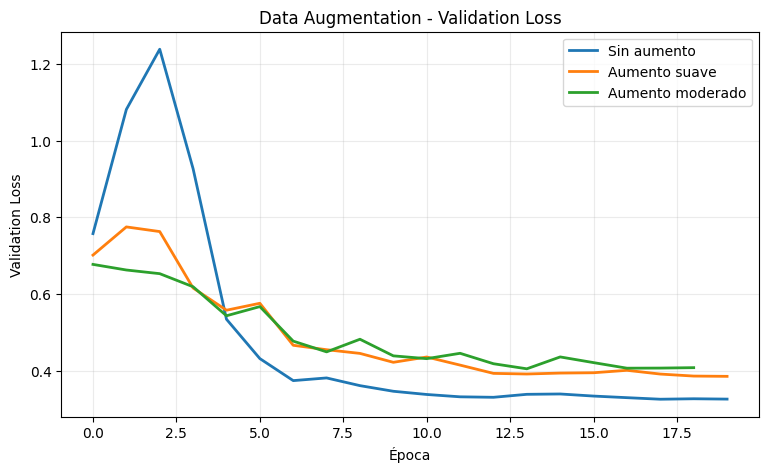

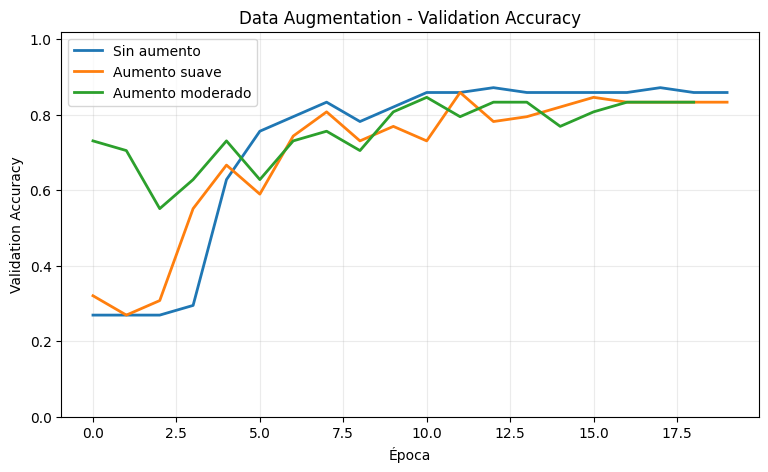

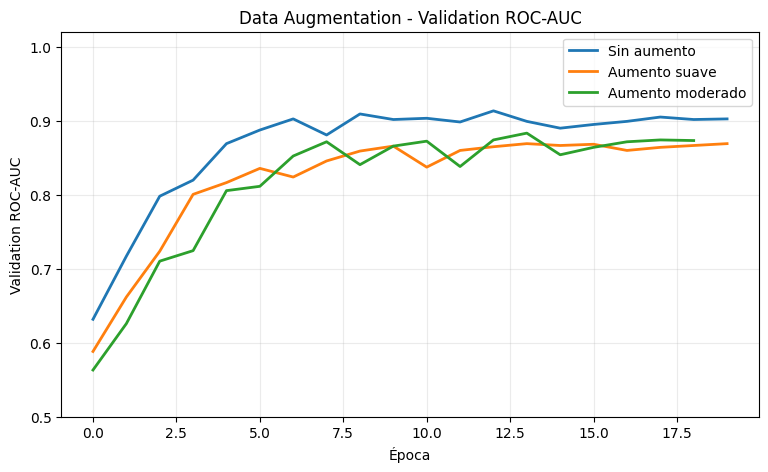

In [23]:
plt.figure(figsize=(9, 5))

for name, history in aug_histories.items():
    plt.plot(
        history["val_loss"],
        linewidth=2,
        label=name
    )

plt.title(
    "Data Augmentation - Validation Loss"
)

plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


plt.figure(figsize=(9, 5))

for name, history in aug_histories.items():
    plt.plot(
        history["val_acc"],
        linewidth=2,
        label=name
    )

plt.title(
    "Data Augmentation - Validation Accuracy"
)

plt.xlabel("Época")
plt.ylabel("Validation Accuracy")
plt.ylim(0, 1.02)
plt.legend()
plt.grid(alpha=0.25)
plt.show()


plt.figure(figsize=(9, 5))

for name, history in aug_histories.items():
    plt.plot(
        history["val_auc"],
        linewidth=2,
        label=name
    )

plt.title(
    "Data Augmentation - Validation ROC-AUC"
)

plt.xlabel("Época")
plt.ylabel("Validation ROC-AUC")
plt.ylim(0.5, 1.02)
plt.legend()
plt.grid(alpha=0.25)
plt.show()

#### Interpretación del Data Augmentation

No es obligatorio que el aumento de datos gane. En un dataset pequeño, una transformación demasiado fuerte puede modificar información útil de la imagen y reducir el rendimiento.

Por eso comparo **Sin aumento**, **Aumento suave** y **Aumento moderado** usando las mismas imágenes de VALIDATION. La opción final se selecciona por ROC-AUC de validación.

In [24]:
print("INTERPRETACIÓN DEL DATA AUGMENTATION")
print("-" * 60)

for _, row in augmentation_results.iterrows():
    print(
        f"{row['Configuración']}: "
        f"Val Loss={row['Mejor Val Loss']:.4f} | "
        f"Val Accuracy={row['Mejor Val Accuracy']:.4f} | "
        f"Val ROC-AUC={row['Mejor Val ROC-AUC']:.4f}"
    )

print()
print(
    "Configuración seleccionada por Validation ROC-AUC:",
    best_aug_name
)

INTERPRETACIÓN DEL DATA AUGMENTATION
------------------------------------------------------------
Sin aumento: Val Loss=0.3252 | Val Accuracy=0.8718 | Val ROC-AUC=0.9131
Aumento suave: Val Loss=0.3849 | Val Accuracy=0.8590 | Val ROC-AUC=0.8688
Aumento moderado: Val Loss=0.4046 | Val Accuracy=0.8462 | Val ROC-AUC=0.8830

Configuración seleccionada por Validation ROC-AUC: Sin aumento


# Ejercicio 4. Dataset diferente

Este ejercicio ya está aplicado durante todo el notebook.

En vez de PneumoniaMNIST o BloodMNIST, utilicé **BreastMNIST**, que:

- pertenece a MedMNIST;
- contiene imágenes de ultrasonido de mama;
- tiene dos clases directamente;
- es bastante pequeño, por lo que sirve bien para una práctica en Colab.

El pipeline fue adaptado a imágenes de **1 canal**.

## 6. Evaluación final de la CNN en TEST

Recién después de seleccionar arquitectura, learning rate y Data Augmentation con VALIDATION, utilizo TEST.

In [25]:
cnn_test = evaluate_network(
    best_cnn_model,
    test_loader,
    criterion
)

print(
    "Mejor configuración de aumento:",
    best_aug_name
)

print(
    f"Test Accuracy: {cnn_test['accuracy']:.4f}"
)

print(
    f"Test ROC-AUC: {cnn_test['auc']:.4f}"
)

print()

print(
    classification_report(
        cnn_test["y_true"],
        cnn_test["y_pred"],
        target_names=class_names,
        digits=4
    )
)

Mejor configuración de aumento: Sin aumento
Test Accuracy: 0.8590
Test ROC-AUC: 0.8601

                precision    recall  f1-score   support

     malignant     0.7778    0.6667    0.7179        42
normal, benign     0.8833    0.9298    0.9060       114

      accuracy                         0.8590       156
     macro avg     0.8306    0.7982    0.8120       156
  weighted avg     0.8549    0.8590    0.8554       156



### Interpretación del resultado final de la CNN

En TEST me interesa principalmente comprobar que el rendimiento se mantenga fuera de TRAIN y VALIDATION.

- **Accuracy** indica el porcentaje total de clasificaciones correctas.
- **ROC-AUC** mide qué tan bien separa el modelo las dos clases.
- **Recall de malignant** es importante porque indica cuántos casos malignos reales logra detectar.

Un ROC-AUC de `1.0` sería una separación perfecta en ese conjunto, pero no se considera automáticamente sobreajuste. Para hablar de sobreajuste se comparan TRAIN, VALIDATION y la pérdida.

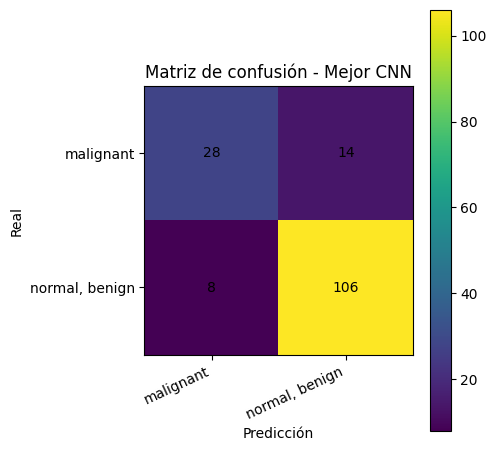

In [26]:
cm_cnn = confusion_matrix(
    cnn_test["y_true"],
    cnn_test["y_pred"]
)

plt.figure(figsize=(5, 5))

plt.imshow(
    cm_cnn
)

plt.title(
    "Matriz de confusión - Mejor CNN"
)

plt.xlabel("Predicción")
plt.ylabel("Real")

plt.xticks(
    [0, 1],
    class_names,
    rotation=25,
    ha="right"
)

plt.yticks(
    [0, 1],
    class_names
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_cnn[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

# Ejercicio 5. Calibración de probabilidades y curva ROC

Para diferenciar este trabajo del ejemplo, en vez de usar **Temperature Scaling** voy a usar **Platt Scaling**.

La idea es:

1. obtener un score del modelo en VALIDATION;
2. ajustar una regresión logística usando solo VALIDATION;
3. aplicar esa calibración a TEST;
4. comparar probabilidades antes y después.

Además de ROC-AUC, incluiré **Brier Score** y una **curva de calibración**, porque permiten comprobar mejor si las probabilidades están bien calibradas.

In [27]:
@torch.no_grad()
def collect_binary_scores(
    model,
    loader
):
    model.eval()

    labels = []
    scores = []
    probs = []

    for x, y in loader:

        x = x.to(
            device,
            non_blocking=True
        )

        y = y.long().view(-1)

        logits = model(x)

        # Diferencia entre logits de clase 1 y clase 0
        score = (
            logits[:, 1]
            - logits[:, 0]
        )

        prob = torch.softmax(
            logits,
            dim=1
        )[:, 1]

        labels.append(
            y.numpy()
        )

        scores.append(
            score.cpu().numpy()
        )

        probs.append(
            prob.cpu().numpy()
        )

    return (
        np.concatenate(labels),
        np.concatenate(scores),
        np.concatenate(probs)
    )


y_val_cal, score_val, prob_val = collect_binary_scores(
    best_cnn_model,
    val_loader
)

y_test_cal, score_test, prob_before = collect_binary_scores(
    best_cnn_model,
    test_loader
)

print(
    "Datos usados para calibrar:",
    len(y_val_cal)
)

print(
    "Datos usados para evaluar:",
    len(y_test_cal)
)

Datos usados para calibrar: 78
Datos usados para evaluar: 156


In [28]:
platt_model = LogisticRegression(
    random_state=SEED
)

platt_model.fit(
    score_val.reshape(-1, 1),
    y_val_cal
)

prob_after = platt_model.predict_proba(
    score_test.reshape(-1, 1)
)[:, 1]

pred_before = (
    prob_before >= 0.5
).astype(int)

pred_after = (
    prob_after >= 0.5
).astype(int)

calibration_results = pd.DataFrame([
    {
        "Estado": "Antes de calibrar",
        "Accuracy": accuracy_score(
            y_test_cal,
            pred_before
        ),
        "ROC-AUC": roc_auc_score(
            y_test_cal,
            prob_before
        ),
        "Brier Score": brier_score_loss(
            y_test_cal,
            prob_before
        )
    },
    {
        "Estado": "Después de Platt Scaling",
        "Accuracy": accuracy_score(
            y_test_cal,
            pred_after
        ),
        "ROC-AUC": roc_auc_score(
            y_test_cal,
            prob_after
        ),
        "Brier Score": brier_score_loss(
            y_test_cal,
            prob_after
        )
    }
])

display(
    calibration_results.round(4)
)

,Estado,Accuracy,ROC-AUC,Brier Score
0,Antes de calibrar,0.8590,0.8601,0.1231
1,Después de Platt Scaling,0.8462,0.8601,0.1157


### 7.1. Curva de calibración

Esta gráfica **no mide Accuracy directamente**. Compara la probabilidad que predice el modelo con la frecuencia real observada.

La línea diagonal representa una calibración ideal. Cuanto más cerca esté la curva de esa diagonal, mejor.

Si algún punto o tramo llega a `1.0`, eso no significa que el modelo esté mal: en ese intervalo simplemente ocurrió que casi todos los ejemplos pertenecían a la clase positiva.

También uso **Brier Score**: en este caso, **menor es mejor**.

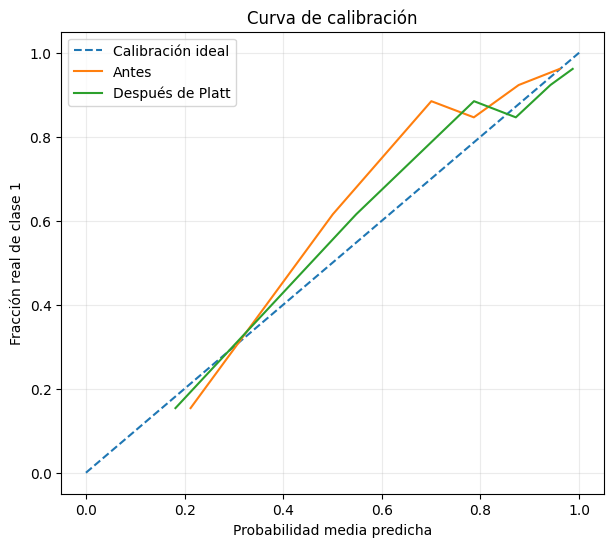

In [29]:
frac_before, mean_before = calibration_curve(
    y_test_cal,
    prob_before,
    n_bins=6,
    strategy="quantile"
)

frac_after, mean_after = calibration_curve(
    y_test_cal,
    prob_after,
    n_bins=6,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Calibración ideal"
)

plt.plot(
    mean_before,
    frac_before,
        label="Antes"
)

plt.plot(
    mean_after,
    frac_after,
        label="Después de Platt"
)

plt.title(
    "Curva de calibración"
)

plt.xlabel(
    "Probabilidad media predicha"
)

plt.ylabel(
    "Fracción real de clase 1"
)

plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [30]:
brier_before_now = brier_score_loss(
    y_test_cal,
    prob_before
)

brier_after_now = brier_score_loss(
    y_test_cal,
    prob_after
)

print("INTERPRETACIÓN DE CALIBRACIÓN")
print("-" * 60)
print(
    f"Brier antes: {brier_before_now:.4f}"
)
print(
    f"Brier después: {brier_after_now:.4f}"
)

if brier_after_now < brier_before_now:
    print(
        "La calibración mejoró la calidad de las probabilidades."
    )
else:
    print(
        "La calibración no mejoró el Brier Score en esta ejecución."
    )

INTERPRETACIÓN DE CALIBRACIÓN
------------------------------------------------------------
Brier antes: 0.1231
Brier después: 0.1157
La calibración mejoró la calidad de las probabilidades.


### 7.2. Curvas ROC antes y después

La curva ROC muestra la capacidad de separar las clases para diferentes umbrales.

Es normal que la curva antes y después de **Platt Scaling** quede casi igual o incluso superpuesta. Platt Scaling cambia la calibración de las probabilidades, pero normalmente conserva su orden, por lo que el ROC-AUC puede mantenerse prácticamente igual.

Una curva más cerca de la esquina superior izquierda representa mejor discriminación. La diagonal representa un clasificador sin capacidad de separación.

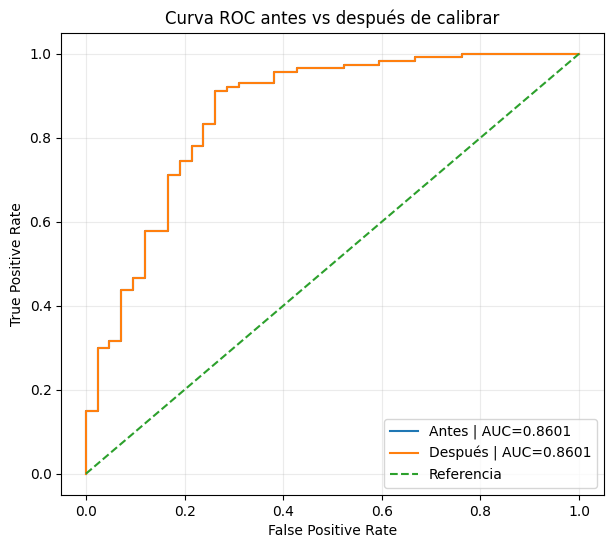

In [31]:
fpr_before, tpr_before, _ = roc_curve(
    y_test_cal,
    prob_before
)

fpr_after, tpr_after, _ = roc_curve(
    y_test_cal,
    prob_after
)

auc_before = roc_auc_score(
    y_test_cal,
    prob_before
)

auc_after = roc_auc_score(
    y_test_cal,
    prob_after
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr_before,
    tpr_before,
    label=f"Antes | AUC={auc_before:.4f}"
)

plt.plot(
    fpr_after,
    tpr_after,
    label=f"Después | AUC={auc_after:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Referencia"
)

plt.title(
    "Curva ROC antes vs después de calibrar"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 8. Transfer Learning con MobileNetV3-Small

Mantengo la parte de Transfer Learning del notebook base, pero cambio la red preentrenada.

En vez de ResNet18 utilizaré **MobileNetV3-Small**, porque es una arquitectura ligera.

Como BreastMNIST tiene un solo canal y los modelos de ImageNet esperan tres canales:

1. redimensiono la imagen;
2. repito el canal gris tres veces;
3. aplico la normalización de ImageNet.

In [32]:
imagenet_mean = (
    0.485,
    0.456,
    0.406
)

imagenet_std = (
    0.229,
    0.224,
    0.225
)

transform_tl_train = T.Compose([
    T.Resize(
        (160, 160)
    ),
    T.RandomRotation(
        degrees=7
    ),
    T.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        scale=(0.97, 1.03)
    ),
    T.ToTensor(),
    T.Lambda(
        lambda x: x.repeat(
            3, 1, 1
        )
    ),
    T.Normalize(
        imagenet_mean,
        imagenet_std
    )
])

transform_tl_eval = T.Compose([
    T.Resize(
        (160, 160)
    ),
    T.ToTensor(),
    T.Lambda(
        lambda x: x.repeat(
            3, 1, 1
        )
    ),
    T.Normalize(
        imagenet_mean,
        imagenet_std
    )
])

train_tl_dataset = DataClass(
    split="train",
    transform=transform_tl_train,
    download=True
)

train_tl_eval_dataset = DataClass(
    split="train",
    transform=transform_tl_eval,
    download=True
)

val_tl_dataset = DataClass(
    split="val",
    transform=transform_tl_eval,
    download=True
)

test_tl_dataset = DataClass(
    split="test",
    transform=transform_tl_eval,
    download=True
)

train_tl_loader = DataLoader(
    train_tl_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=device.type == "cuda"
)

train_tl_eval_loader = DataLoader(
    train_tl_eval_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=device.type == "cuda"
)

val_tl_loader = DataLoader(
    val_tl_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=device.type == "cuda"
)

test_tl_loader = DataLoader(
    test_tl_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=device.type == "cuda"
)

x_tl, _ = next(
    iter(train_tl_loader)
)

print(
    "Forma del batch para MobileNet:",
    x_tl.shape
)

Forma del batch para MobileNet: torch.Size([32, 3, 160, 160])


### 8.1. Primera etapa: entrenar el clasificador

Primero congelo el extractor de características y entreno solamente el clasificador final.

In [33]:
weights = models.MobileNet_V3_Small_Weights.DEFAULT

mobilenet = models.mobilenet_v3_small(
    weights=weights
)

for param in mobilenet.parameters():
    param.requires_grad = False

in_features = mobilenet.classifier[-1].in_features

mobilenet.classifier[-1] = nn.Linear(
    in_features,
    2
)

for param in mobilenet.classifier.parameters():
    param.requires_grad = True

mobilenet = mobilenet.to(
    device
)

print(
    "Capas entrenables en etapa 1:",
    sum(
        p.numel()
        for p in mobilenet.parameters()
        if p.requires_grad
    )
)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 95.3MB/s]

Capas entrenables en etapa 1: 592898


In [34]:
mobilenet, history_tl_head = fit_model(
    mobilenet,
    train_tl_loader,
    val_tl_loader,
    train_eval_dl=train_tl_eval_loader,
    lr=3e-4,
    scheduler_kind="plateau",
    epochs=10,
    patience=4,
    verbose=True
)

# Guardo el mejor estado de la etapa 1 antes de hacer fine-tuning.
stage1_state = copy.deepcopy(
    mobilenet.state_dict()
)

stage1_val = evaluate_network(
    mobilenet,
    val_tl_loader,
    criterion
)

Época 01 | train_loss=0.6687 | val_loss=0.6045 | train_acc=0.7747 | val_acc=0.8077 | train_auc=0.7118 | val_auc=0.7627 | lr=3.00e-04
Época 02 | train_loss=0.5732 | val_loss=0.5888 | train_acc=0.7601 | val_acc=0.7821 | train_auc=0.7011 | val_auc=0.7577 | lr=3.00e-04
Época 03 | train_loss=0.5450 | val_loss=0.5930 | train_acc=0.7491 | val_acc=0.7692 | train_auc=0.7048 | val_auc=0.7644 | lr=3.00e-04
Época 04 | train_loss=0.5252 | val_loss=0.5992 | train_acc=0.7491 | val_acc=0.7564 | train_auc=0.7176 | val_auc=0.7861 | lr=3.00e-04
Época 05 | train_loss=0.5244 | val_loss=0.6469 | train_acc=0.7473 | val_acc=0.7436 | train_auc=0.7234 | val_auc=0.7611 | lr=3.00e-04
Época 06 | train_loss=0.5421 | val_loss=0.7025 | train_acc=0.7454 | val_acc=0.7436 | train_auc=0.7389 | val_auc=0.7310 | lr=1.50e-04
Early stopping.


### 8.2. Fine-tuning

Ahora descongelo los últimos tres bloques de características para que MobileNet se adapte un poco más al dataset.

In [35]:
# Descongelo solo los dos últimos bloques para hacer un ajuste más conservador.
for param in mobilenet.features[-2:].parameters():
    param.requires_grad = True

for param in mobilenet.classifier.parameters():
    param.requires_grad = True

mobilenet, history_tl_ft = fit_model(
    mobilenet,
    train_tl_loader,
    val_tl_loader,
    train_eval_dl=train_tl_eval_loader,
    lr=2e-5,
    scheduler_kind="plateau",
    epochs=10,
    patience=4,
    verbose=True
)

stage2_val = evaluate_network(
    mobilenet,
    val_tl_loader,
    criterion
)

# Si el fine-tuning empeora VALIDATION, regreso al mejor estado anterior.
if stage2_val["loss"] > stage1_val["loss"]:
    mobilenet.load_state_dict(
        stage1_state
    )

    transfer_choice = "Etapa 1 (clasificador congelando backbone)"

    print(
        "El fine-tuning no mejoró Validation Loss; "
        "se conserva el mejor estado de la etapa 1."
    )
else:
    transfer_choice = "Fine-tuning"

    print(
        "El fine-tuning mejoró Validation Loss; "
        "se conserva el modelo ajustado."
    )

Época 01 | train_loss=0.5519 | val_loss=0.6000 | train_acc=0.7473 | val_acc=0.7821 | train_auc=0.6803 | val_auc=0.7435 | lr=2.00e-05
Época 02 | train_loss=0.5418 | val_loss=0.6129 | train_acc=0.7473 | val_acc=0.7692 | train_auc=0.6725 | val_auc=0.7427 | lr=2.00e-05
Época 03 | train_loss=0.5228 | val_loss=0.6367 | train_acc=0.7491 | val_acc=0.7436 | train_auc=0.6743 | val_auc=0.7168 | lr=2.00e-05
Época 04 | train_loss=0.5097 | val_loss=0.6812 | train_acc=0.7473 | val_acc=0.7436 | train_auc=0.6807 | val_auc=0.6834 | lr=2.00e-05
Época 05 | train_loss=0.5100 | val_loss=0.7229 | train_acc=0.7454 | val_acc=0.7308 | train_auc=0.6969 | val_auc=0.6475 | lr=1.00e-05
Early stopping.
El fine-tuning no mejoró Validation Loss; se conserva el mejor estado de la etapa 1.


### 8.3. Curvas e interpretación del Transfer Learning

En Transfer Learning no es obligatorio que el modelo preentrenado supere a la CNN desde cero. BreastMNIST es pequeño y además las imágenes de ultrasonido son muy diferentes de las fotografías de ImageNet.

Si durante fine-tuning TRAIN mejora pero Validation Loss aumenta, eso sí es una señal de **sobreajuste**. Por esa razón conservo automáticamente la etapa que tenga menor Validation Loss.

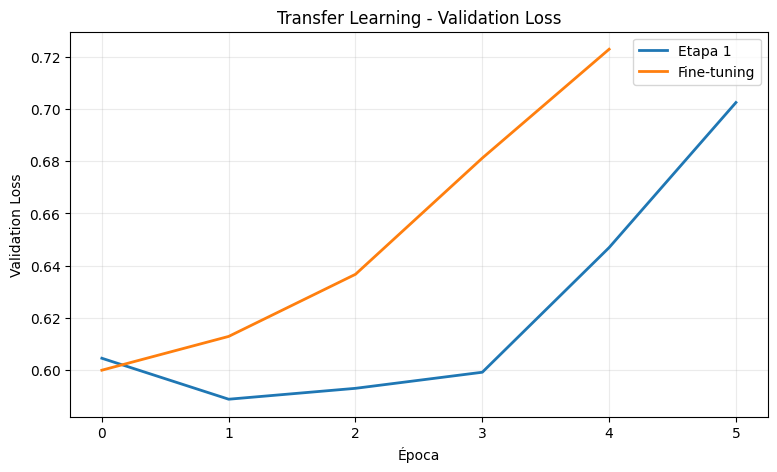

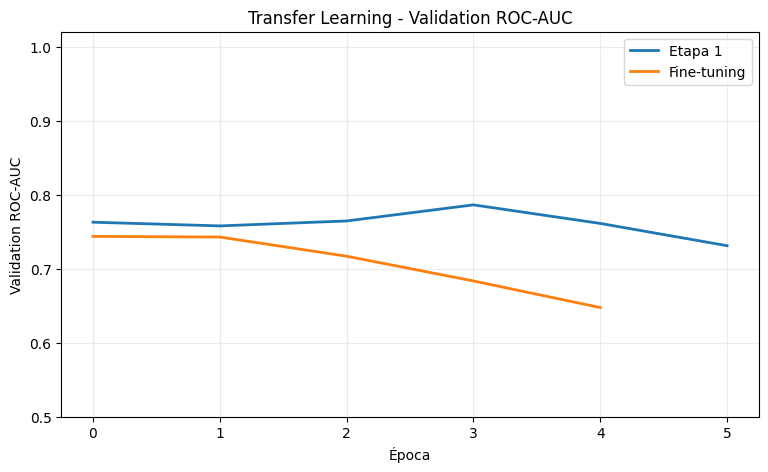

Modelo conservado para TEST: Etapa 1 (clasificador congelando backbone)


In [36]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_tl_head["val_loss"],
    linewidth=2,
    label="Etapa 1"
)

plt.plot(
    history_tl_ft["val_loss"],
    linewidth=2,
    label="Fine-tuning"
)

plt.title(
    "Transfer Learning - Validation Loss"
)

plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


plt.figure(figsize=(9, 5))

plt.plot(
    history_tl_head["val_auc"],
    linewidth=2,
    label="Etapa 1"
)

plt.plot(
    history_tl_ft["val_auc"],
    linewidth=2,
    label="Fine-tuning"
)

plt.title(
    "Transfer Learning - Validation ROC-AUC"
)

plt.xlabel("Época")
plt.ylabel("Validation ROC-AUC")
plt.ylim(0.5, 1.02)
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print(
    "Modelo conservado para TEST:",
    transfer_choice
)

In [37]:
tl_test = evaluate_network(
    mobilenet,
    test_tl_loader,
    criterion
)

print(
    f"MobileNetV3 - Test Accuracy: {tl_test['accuracy']:.4f}"
)

print(
    f"MobileNetV3 - Test ROC-AUC: {tl_test['auc']:.4f}"
)

print()

print(
    classification_report(
        tl_test["y_true"],
        tl_test["y_pred"],
        target_names=class_names,
        digits=4
    )
)

MobileNetV3 - Test Accuracy: 0.7372
MobileNetV3 - Test ROC-AUC: 0.6393

                precision    recall  f1-score   support

     malignant     0.6000    0.0714    0.1277        42
normal, benign     0.7417    0.9825    0.8453       114

      accuracy                         0.7372       156
     macro avg     0.6709    0.5269    0.4865       156
  weighted avg     0.7036    0.7372    0.6521       156



## 9. Comparación global

Finalmente comparo la mejor CNN entrenada desde cero y MobileNetV3 con Transfer Learning.

Esta tabla es descriptiva: no vuelvo a ajustar los modelos usando TEST.

In [38]:
global_results = pd.DataFrame([
    {
        "Modelo": "Mejor CNN desde cero",
        "Accuracy TEST": cnn_test["accuracy"],
        "ROC-AUC TEST": cnn_test["auc"]
    },
    {
        "Modelo": "MobileNetV3 + Fine-tuning",
        "Accuracy TEST": tl_test["accuracy"],
        "ROC-AUC TEST": tl_test["auc"]
    }
])

display(
    global_results.round(4)
)

,Modelo,Accuracy TEST,ROC-AUC TEST
0,Mejor CNN desde cero,0.8590,0.8601
1,MobileNetV3 + Fine-tuning,0.7372,0.6393


## 10. Grad-CAM

Para mantener la parte de interpretabilidad, aplicaré Grad-CAM sobre la última parte convolucional de MobileNetV3.

El mapa muestra qué regiones de la imagen tuvieron mayor influencia en la predicción del modelo.

In [39]:
def grad_cam_mobilenet(
    model,
    image_tensor,
    target_class=None
):
    model.eval()

    saved = {}

    target_layer = model.features[-1]

    def save_activation(
        module,
        inputs,
        output
    ):
        saved["activation"] = output
        output.retain_grad()

    handle = target_layer.register_forward_hook(
        save_activation
    )

    x = image_tensor.unsqueeze(
        0
    ).to(device)

    logits = model(x)

    if target_class is None:
        target_class = int(
            torch.argmax(
                logits,
                dim=1
            ).item()
        )

    score = logits[
        0,
        target_class
    ]

    model.zero_grad(
        set_to_none=True
    )

    score.backward()

    activation = saved[
        "activation"
    ][0]

    gradient = saved[
        "activation"
    ].grad[0]

    weights_cam = gradient.mean(
        dim=(1, 2)
    )

    cam = (
        weights_cam[:, None, None]
        * activation
    ).sum(dim=0)

    cam = torch.relu(cam)

    cam = cam - cam.min()

    cam = cam / (
        cam.max() + 1e-8
    )

    handle.remove()

    return (
        cam.detach().cpu().numpy(),
        target_class
    )

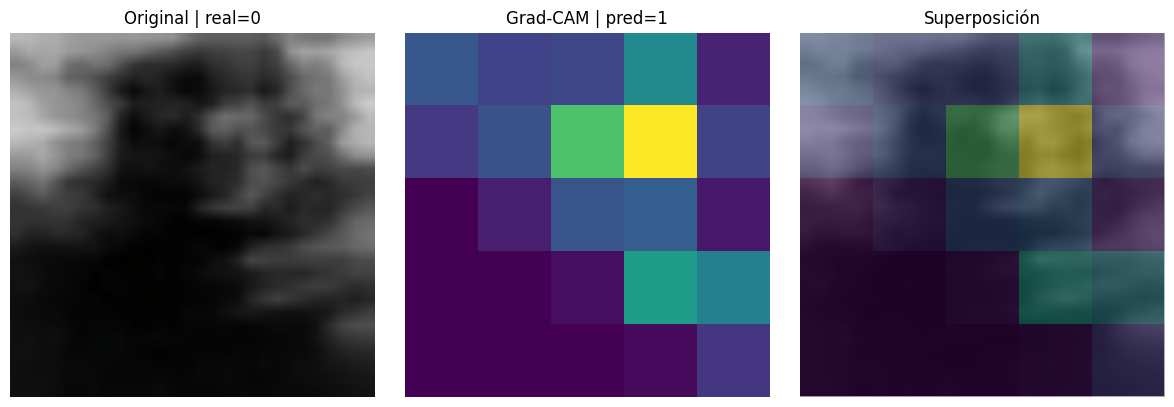

In [40]:
idx = 0

x_cam, y_cam = test_tl_dataset[
    idx
]

cam, pred_cam = grad_cam_mobilenet(
    mobilenet,
    x_cam
)

img = (
    x_cam.permute(
        1, 2, 0
    ).cpu().numpy()
)

img = (
    img * np.array(
        imagenet_std
    )
    + np.array(
        imagenet_mean
    )
)

img = np.clip(
    img,
    0,
    1
)

real_class = int(
    np.asarray(y_cam).squeeze()
)

plt.figure(
    figsize=(12, 4)
)

plt.subplot(
    1, 3, 1
)

plt.imshow(img)

plt.title(
    f"Original | real={real_class}"
)

plt.axis("off")


plt.subplot(
    1, 3, 2
)

plt.imshow(cam)

plt.title(
    f"Grad-CAM | pred={pred_cam}"
)

plt.axis("off")


plt.subplot(
    1, 3, 3
)

plt.imshow(img)

plt.imshow(
    cam,
    alpha=0.45,
    extent=(
        0,
        img.shape[1],
        img.shape[0],
        0
    )
)

plt.title(
    "Superposición"
)

plt.axis("off")

plt.tight_layout()
plt.show()

## 11. Guardar los modelos

Guardo la CNN final, MobileNetV3 y los parámetros aprendidos por Platt Scaling.

In [41]:
os.makedirs(
    "models",
    exist_ok=True
)

torch.save(
    best_cnn_model.state_dict(),
    "models/best_cnn_breastmnist.pth"
)

torch.save(
    mobilenet.state_dict(),
    "models/mobilenetv3_breastmnist.pth"
)

np.savez(
    "models/platt_scaling_breastmnist.npz",
    coef=platt_model.coef_,
    intercept=platt_model.intercept_
)

print("Archivos guardados:")
print(" - models/best_cnn_breastmnist.pth")
print(" - models/mobilenetv3_breastmnist.pth")
print(" - models/platt_scaling_breastmnist.npz")

Archivos guardados:
 - models/best_cnn_breastmnist.pth
 - models/mobilenetv3_breastmnist.pth
 - models/platt_scaling_breastmnist.npz


## 12. Resumen final

Con este notebook quedan desarrollados los cinco ejercicios:

- **Arquitectura:** comparé una CNN base con otra que usa más filtros, BatchNorm y Dropout.
- **Learning rate y scheduler:** comparé tres configuraciones con tasas más estables y CosineAnnealingLR.
- **Data Augmentation:** comparé sin aumento, aumento suave y aumento moderado.
- **Cambio de dataset:** todo el pipeline fue adaptado a BreastMNIST.
- **Calibración + ROC:** utilicé Platt Scaling, Brier Score, curva de calibración y curvas ROC.

También mantuve Transfer Learning, matriz de confusión, Classification Report, guardado del modelo y Grad-CAM.

### Cómo interpreto las gráficas

- **Loss:** lo esperado es que disminuya. Si Train Loss baja mientras Validation Loss empieza a subir, aparece sobreajuste.
- **Accuracy:** valores altos son mejores, pero no se deben analizar solos porque las clases están desbalanceadas.
- **ROC-AUC:** `0.5` ≈ azar, `0.6` es débil, `0.7` moderado, `0.8` bueno y `0.9` o más es alto.
- **Llegar a 1.0 no es automáticamente malo.** Se vuelve sospechoso cuando TRAIN es casi perfecto y VALIDATION/TEST no acompaña.
- **Early stopping** permite colocar un máximo mayor de épocas sin obligar al modelo a entrenar de más.
- En todas las decisiones de configuración utilizo **VALIDATION**. TEST queda reservado para la evaluación final.

In [42]:
print("RESUMEN DE LA EJECUCIÓN")
print("-" * 55)

print(
    "Mejor configuración de Learning Rate:",
    best_lr_name
)

print(
    "Mejor Data Augmentation:",
    best_aug_name
)

print(
    f"CNN final -> Accuracy={cnn_test['accuracy']:.4f} | "
    f"ROC-AUC={cnn_test['auc']:.4f}"
)

print(
    f"MobileNetV3 -> Accuracy={tl_test['accuracy']:.4f} | "
    f"ROC-AUC={tl_test['auc']:.4f}"
)

brier_before = brier_score_loss(
    y_test_cal,
    prob_before
)

brier_after = brier_score_loss(
    y_test_cal,
    prob_after
)

print(
    f"Brier antes={brier_before:.4f} | "
    f"Brier después={brier_after:.4f}"
)

if brier_after < brier_before:
    print(
        "La calibración mejoró el Brier Score en esta ejecución."
    )
else:
    print(
        "La calibración no mejoró el Brier Score en esta ejecución."
    )

RESUMEN DE LA EJECUCIÓN
-------------------------------------------------------
Mejor configuración de Learning Rate: LR 0.0005 + Cosine
Mejor Data Augmentation: Sin aumento
CNN final -> Accuracy=0.8590 | ROC-AUC=0.8601
MobileNetV3 -> Accuracy=0.7372 | ROC-AUC=0.6393
Brier antes=0.1231 | Brier después=0.1157
La calibración mejoró el Brier Score en esta ejecución.
